# ***Problem Statement***

Calories burnt by a person while performing exercise is to be calculated. Hence, it is a problem of Regression.

The target variable is *Calories* and will be evaluated using RMSE.

# ***Dataset Loading***

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df_1 = pd.read_csv('calories.csv') #contains user id and calories burnt
df_2 = pd.read_csv('exercise.csv') #contains user id and other necessary features

In [3]:
# concatinating the two dataframes
df = pd.concat([df_2, df_1], axis=1)

# ***Sanity Check***

In [4]:
# first 5 rows of the dataframe
df.head()

,User_ID,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,User_ID,Calories
0,14733363,male,68,190.0,94.0,29.0,105.0,40.8,14733363,231.0
1,14861698,female,20,166.0,60.0,14.0,94.0,40.3,14861698,66.0
2,11179863,male,69,179.0,79.0,5.0,88.0,38.7,11179863,26.0
3,16180408,female,34,179.0,71.0,13.0,100.0,40.5,16180408,71.0
4,17771927,female,27,154.0,58.0,10.0,81.0,39.8,17771927,35.0


In [5]:
# shape of the dataset
df.shape

(15000, 10)

In [6]:
# information of the dataframe
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   User_ID     15000 non-null  int64  
 1   Gender      15000 non-null  str    
 2   Age         15000 non-null  int64  
 3   Height      15000 non-null  float64
 4   Weight      15000 non-null  float64
 5   Duration    15000 non-null  float64
 6   Heart_Rate  15000 non-null  float64
 7   Body_Temp   15000 non-null  float64
 8   User_ID     15000 non-null  int64  
 9   Calories    15000 non-null  float64
dtypes: float64(6), int64(3), str(1)
memory usage: 1.2 MB


In [7]:
# number of missing values
df.isnull().sum()

User_ID       0
Gender        0
Age           0
Height        0
Weight        0
Duration      0
Heart_Rate    0
Body_Temp     0
User_ID       0
Calories      0
dtype: int64

In [8]:
# number of duplicate values
df.duplicated().sum()

np.int64(0)

# ***Exploratory Data Analysis***

In [9]:
df.describe()

,User_ID,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,User_ID,Calories
count,1.500000e+04,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,1.500000e+04,15000.000000
mean,1.497736e+07,42.789800,174.465133,74.966867,15.530600,95.518533,40.025453,1.497736e+07,89.539533
std,2.872851e+06,16.980264,14.258114,15.035657,8.319203,9.583328,0.779230,2.872851e+06,62.456978
min,1.000116e+07,20.000000,123.000000,36.000000,1.000000,67.000000,37.100000,1.000116e+07,1.000000
25%,1.247419e+07,28.000000,164.000000,63.000000,8.000000,88.000000,39.600000,1.247419e+07,35.000000
50%,1.499728e+07,39.000000,175.000000,74.000000,16.000000,96.000000,40.200000,1.499728e+07,79.000000
75%,1.744928e+07,56.000000,185.000000,87.000000,23.000000,103.000000,40.600000,1.744928e+07,138.000000
max,1.999965e+07,79.000000,222.000000,132.000000,30.000000,128.000000,41.500000,1.999965e+07,314.000000


In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   User_ID     15000 non-null  int64  
 1   Gender      15000 non-null  str    
 2   Age         15000 non-null  int64  
 3   Height      15000 non-null  float64
 4   Weight      15000 non-null  float64
 5   Duration    15000 non-null  float64
 6   Heart_Rate  15000 non-null  float64
 7   Body_Temp   15000 non-null  float64
 8   User_ID     15000 non-null  int64  
 9   Calories    15000 non-null  float64
dtypes: float64(6), int64(3), str(1)
memory usage: 1.2 MB


In [11]:
df['Gender'].value_counts()

Gender
female    7553
male      7447
Name: count, dtype: int64

In [12]:
df.columns

Index(['User_ID', 'Gender', 'Age', 'Height', 'Weight', 'Duration',
       'Heart_Rate', 'Body_Temp', 'User_ID', 'Calories'],
      dtype='str')

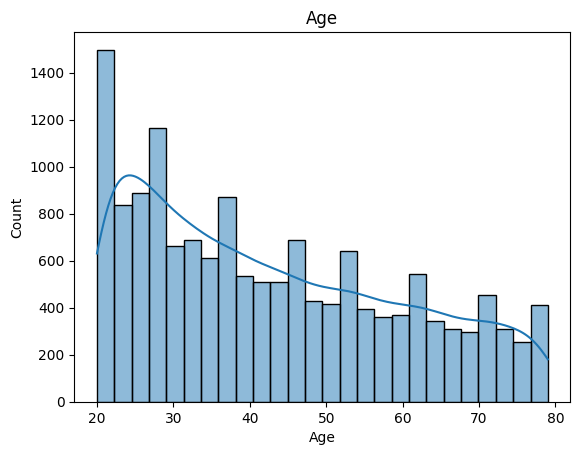

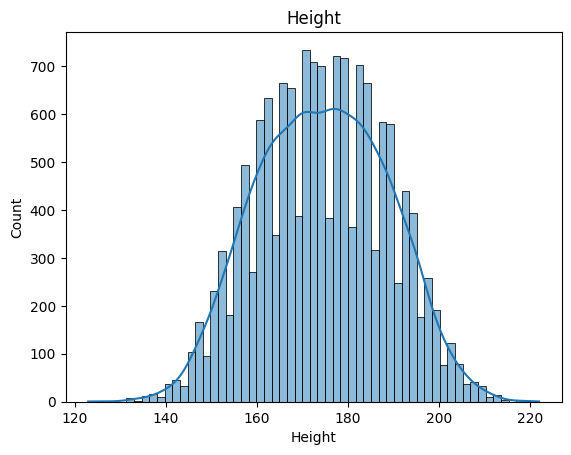

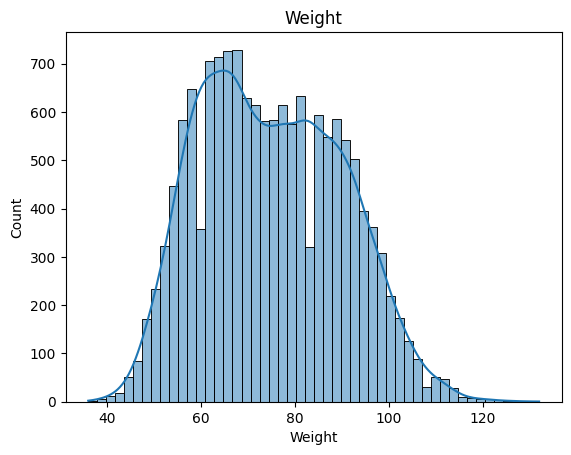

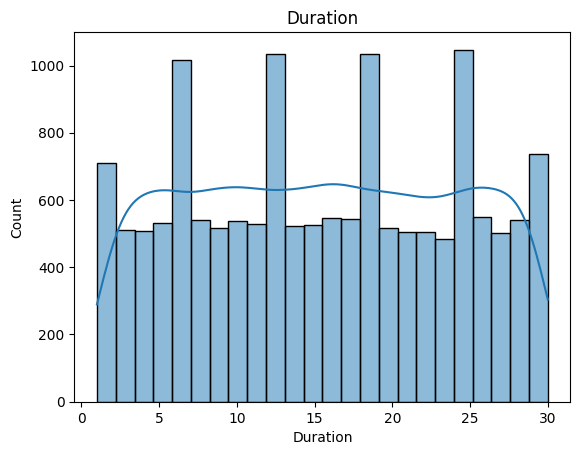

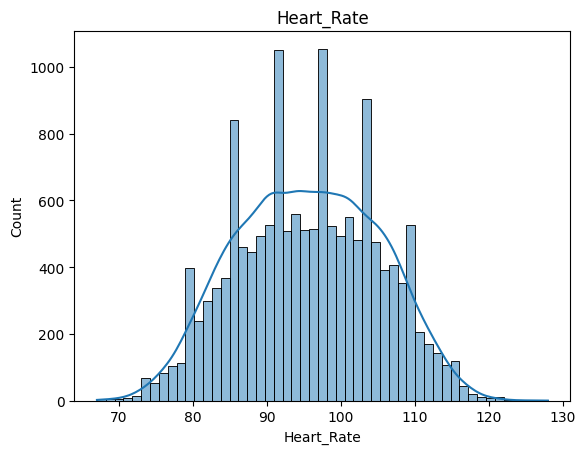

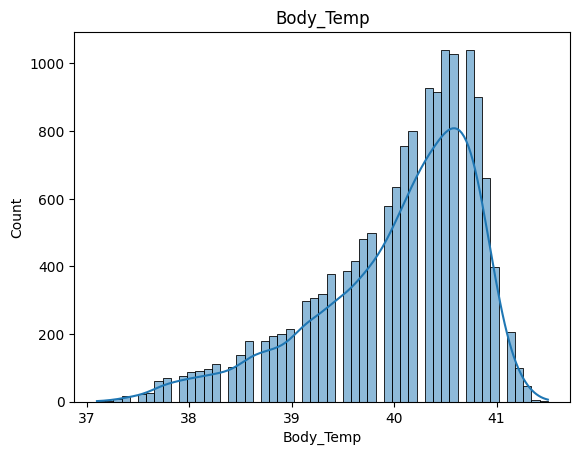

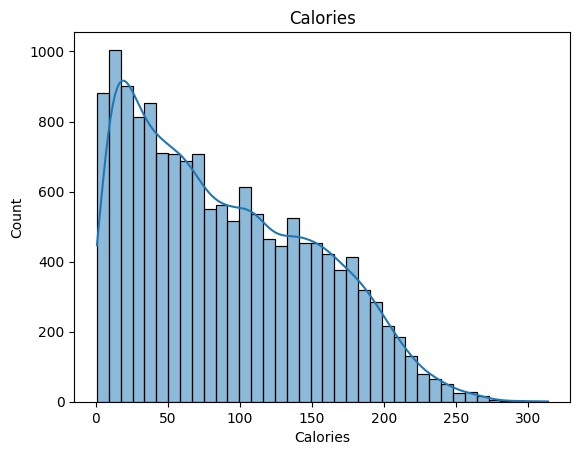

In [13]:
# creating distribution plot for all features and target

for i in ['Age', 'Height', 'Weight', 'Duration',
       'Heart_Rate', 'Body_Temp', 'Calories']:
    sns.histplot(df[i], kde=True)
    plt.title(i)
    plt.show()

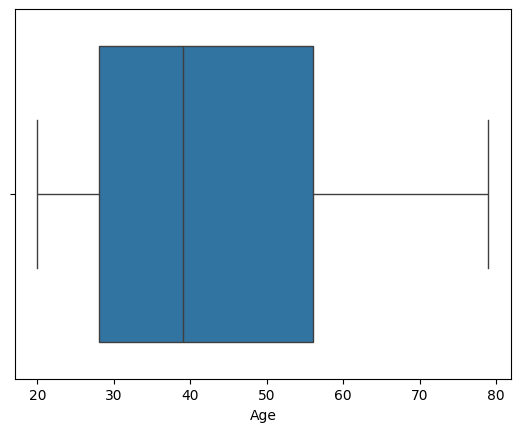

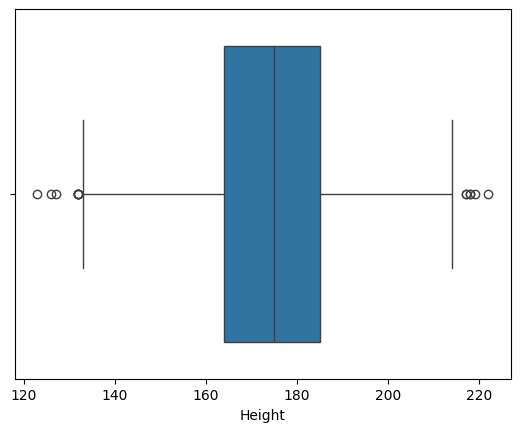

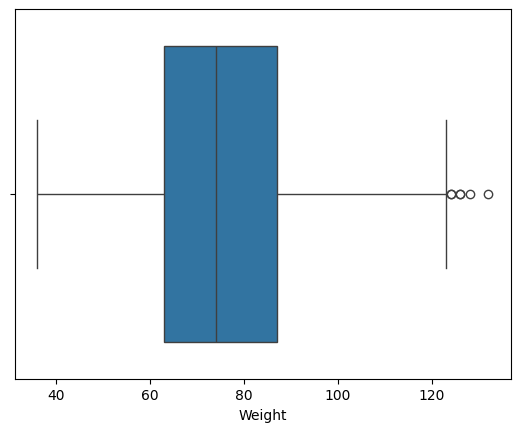

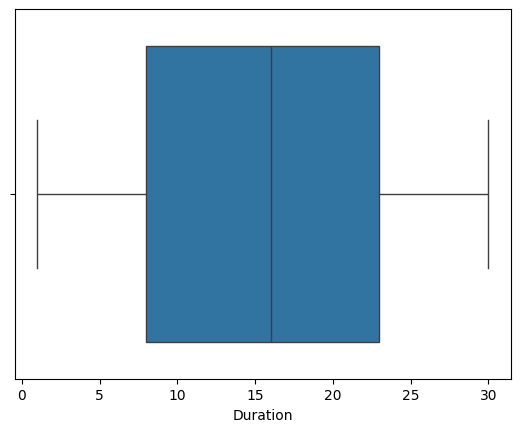

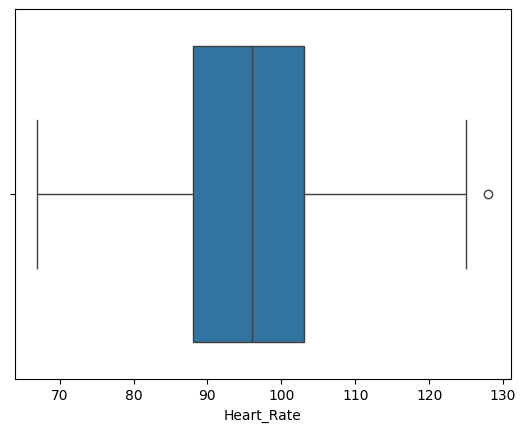

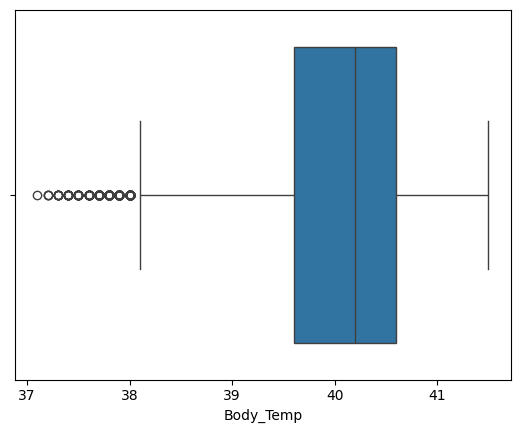

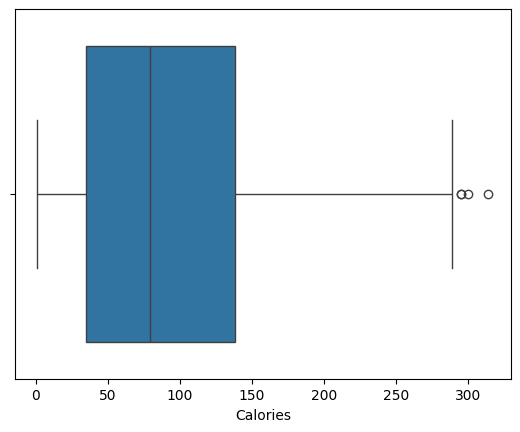

In [14]:
# creating boxplot for all features and target to find ouliers

for i in ['Age', 'Height', 'Weight', 'Duration',
       'Heart_Rate', 'Body_Temp', 'Calories']:
    sns.boxplot(x = df[i])
    plt.show()

In [15]:
# finding skew value

for i in ['Age', 'Height', 'Weight', 'Duration',
       'Heart_Rate', 'Body_Temp', 'Calories']:
    print(f'{i} : {df[i].skew()}')

Age : 0.47338270096138746
Height : -0.006189620437893532
Weight : 0.22672530725814513
Duration : 0.004750536668097847
Heart_Rate : -0.010704079728548947
Body_Temp : -0.9943824155974582
Calories : 0.5053713740451047


0 = Normal, <0 = left skewed, >0 = right skewed

In [16]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   User_ID     15000 non-null  int64  
 1   Gender      15000 non-null  str    
 2   Age         15000 non-null  int64  
 3   Height      15000 non-null  float64
 4   Weight      15000 non-null  float64
 5   Duration    15000 non-null  float64
 6   Heart_Rate  15000 non-null  float64
 7   Body_Temp   15000 non-null  float64
 8   User_ID     15000 non-null  int64  
 9   Calories    15000 non-null  float64
dtypes: float64(6), int64(3), str(1)
memory usage: 1.2 MB


<Axes: >

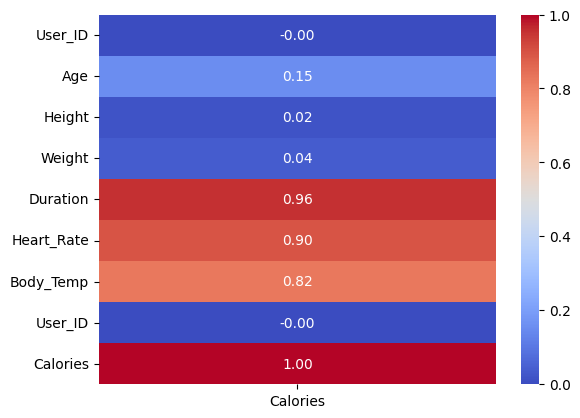

In [17]:
# correlation of different features
correlation = df.select_dtypes(include=['int64','float64']).corr()[['Calories']]

sns.heatmap(correlation, cbar=True, fmt='.2f', annot = True, cmap = 'coolwarm')

Duration, Heart_Rate and Body_Temp are strongly correlated with Calories(Target)

In [18]:
df.describe()

,User_ID,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,User_ID,Calories
count,1.500000e+04,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,1.500000e+04,15000.000000
mean,1.497736e+07,42.789800,174.465133,74.966867,15.530600,95.518533,40.025453,1.497736e+07,89.539533
std,2.872851e+06,16.980264,14.258114,15.035657,8.319203,9.583328,0.779230,2.872851e+06,62.456978
min,1.000116e+07,20.000000,123.000000,36.000000,1.000000,67.000000,37.100000,1.000116e+07,1.000000
25%,1.247419e+07,28.000000,164.000000,63.000000,8.000000,88.000000,39.600000,1.247419e+07,35.000000
50%,1.499728e+07,39.000000,175.000000,74.000000,16.000000,96.000000,40.200000,1.499728e+07,79.000000
75%,1.744928e+07,56.000000,185.000000,87.000000,23.000000,103.000000,40.600000,1.744928e+07,138.000000
max,1.999965e+07,79.000000,222.000000,132.000000,30.000000,128.000000,41.500000,1.999965e+07,314.000000


In [19]:
# Compute mean, std, min, max target per group
df.groupby('Gender')['Calories'].describe()

,count,mean,std,min,25%,50%,75%,max
Gender,,,,,,,,
female,7553.0,88.153052,58.586980,2.0,36.0,80.0,135.0,240.0
male,7447.0,90.945750,66.125478,1.0,34.0,78.0,140.0,314.0


In [20]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   User_ID     15000 non-null  int64  
 1   Gender      15000 non-null  str    
 2   Age         15000 non-null  int64  
 3   Height      15000 non-null  float64
 4   Weight      15000 non-null  float64
 5   Duration    15000 non-null  float64
 6   Heart_Rate  15000 non-null  float64
 7   Body_Temp   15000 non-null  float64
 8   User_ID     15000 non-null  int64  
 9   Calories    15000 non-null  float64
dtypes: float64(6), int64(3), str(1)
memory usage: 1.2 MB


*Checking Linearity*

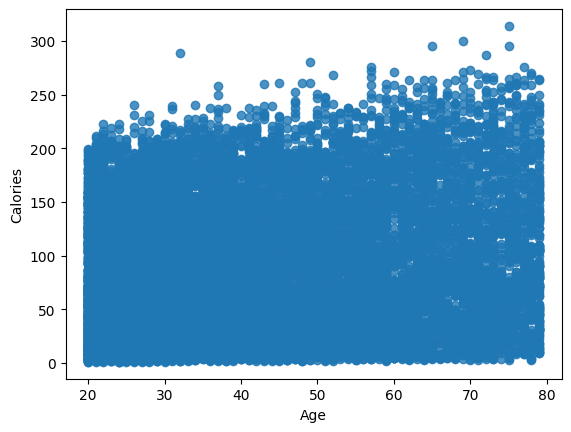

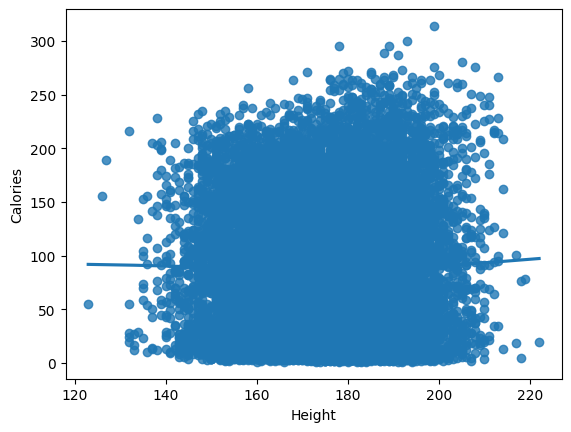

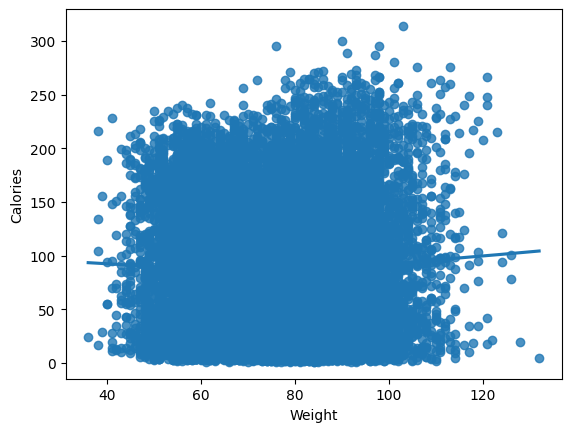

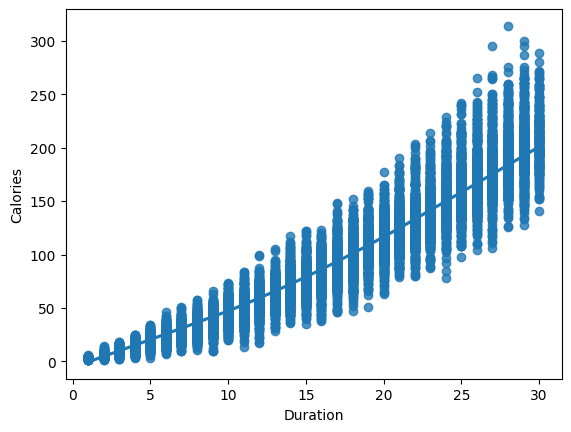

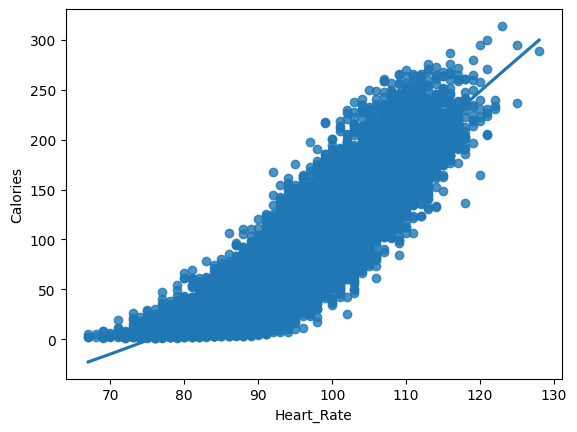

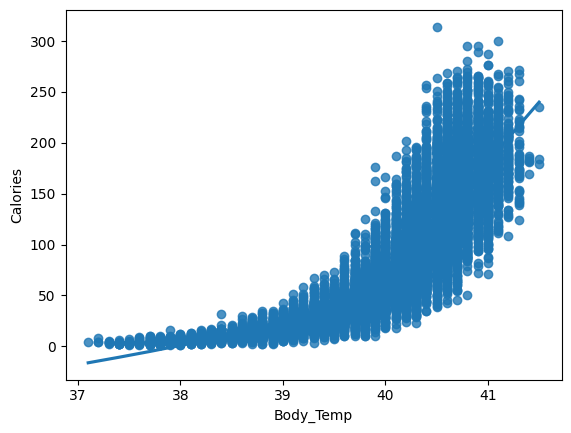

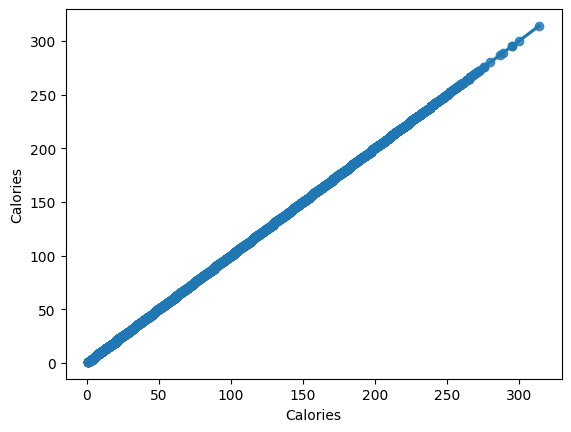

In [21]:
import statsmodels
for i in ['Age', 'Height', 'Weight', 'Duration',
       'Heart_Rate', 'Body_Temp', 'Calories']:
    sns.regplot(
        x = df[i],
        y = df['Calories'],
        lowess = True)
    plt.show()

The relationship of different features with target are most of the tine non linear. so LinearRegression may underfit.

# ***Data Preprocessing***

In [22]:
# # dropping the similar columns
# df = df.T.drop_duplicates().T

In [23]:
# encoding the categorical features into numerical values
df['Gender'] = df['Gender'].replace({'male':0,'female':1}) 

In [24]:
df.head(1)

,User_ID,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,User_ID,Calories
0,14733363,0,68,190.0,94.0,29.0,105.0,40.8,14733363,231.0


In [25]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   User_ID     15000 non-null  int64  
 1   Gender      15000 non-null  object 
 2   Age         15000 non-null  int64  
 3   Height      15000 non-null  float64
 4   Weight      15000 non-null  float64
 5   Duration    15000 non-null  float64
 6   Heart_Rate  15000 non-null  float64
 7   Body_Temp   15000 non-null  float64
 8   User_ID     15000 non-null  int64  
 9   Calories    15000 non-null  float64
dtypes: float64(6), int64(3), object(1)
memory usage: 1.1+ MB


In [26]:
df['Gender'] = df['Gender'].astype(int)

In [27]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   User_ID     15000 non-null  int64  
 1   Gender      15000 non-null  int64  
 2   Age         15000 non-null  int64  
 3   Height      15000 non-null  float64
 4   Weight      15000 non-null  float64
 5   Duration    15000 non-null  float64
 6   Heart_Rate  15000 non-null  float64
 7   Body_Temp   15000 non-null  float64
 8   User_ID     15000 non-null  int64  
 9   Calories    15000 non-null  float64
dtypes: float64(6), int64(4)
memory usage: 1.1 MB


# ***Train_Test_Split***

In [28]:
X = df.drop(columns=['User_ID', 'Calories'])
y = df['Calories']

In [71]:
dataset = pd.concat([X,y], axis=1)

In [72]:
dataset.head(0)

,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories


In [73]:
dataset.to_csv('customized_data.csv', index=False)

In [29]:
print(X)
print(y)

       Gender  Age  Height  Weight  Duration  Heart_Rate  Body_Temp
0           0   68   190.0    94.0      29.0       105.0       40.8
1           1   20   166.0    60.0      14.0        94.0       40.3
2           0   69   179.0    79.0       5.0        88.0       38.7
3           1   34   179.0    71.0      13.0       100.0       40.5
4           1   27   154.0    58.0      10.0        81.0       39.8
...       ...  ...     ...     ...       ...         ...        ...
14995       1   20   193.0    86.0      11.0        92.0       40.4
14996       1   27   165.0    65.0       6.0        85.0       39.2
14997       1   43   159.0    58.0      16.0        90.0       40.1
14998       0   78   193.0    97.0       2.0        84.0       38.3
14999       0   63   173.0    79.0      18.0        92.0       40.5

[15000 rows x 7 columns]
0        231.0
1         66.0
2         26.0
3         71.0
4         35.0
         ...  
14995     45.0
14996     23.0
14997     75.0
14998     11.0
14999   

In [30]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=2)

In [82]:
train = pd.concat([X_train, y_train], axis=1)
test = pd.concat([X_test, y_test], axis=1)

In [83]:
train.to_csv('train.csv')
test.to_csv('test.csv')

In [31]:
print(X.shape, X_train.shape, X_test.shape)
print(y.shape, y_train.shape, y_test.shape)

(15000, 7) (12000, 7) (3000, 7)
(15000,) (12000,) (3000,)


# ***Model Training***

In [32]:
from sklearn.linear_model import LinearRegression

In [33]:
lin_reg_model = LinearRegression()

In [34]:
lin_reg_model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [35]:
training_data_prediction = lin_reg_model.predict(X_train)


In [36]:
from sklearn import metrics

mse = metrics.mean_squared_error(y_train, training_data_prediction)
rmse = metrics.root_mean_squared_error(y_train, training_data_prediction)
r2_score = metrics.r2_score(y_train, training_data_prediction)

print(f'mse = {mse} , rmse = {rmse} and r2_score = {r2_score}')

mse = 127.42140884200921 , rmse = 11.288109179220815 and r2_score = 0.9672762198112508


In [37]:
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from catboost import CatBoostRegressor

In [38]:
models = [
    RandomForestRegressor(n_estimators=100),
    XGBRegressor(),
    CatBoostRegressor(verbose=0)
]

In [39]:
print(df.dtypes)

User_ID         int64
Gender          int64
Age             int64
Height        float64
Weight        float64
Duration      float64
Heart_Rate    float64
Body_Temp     float64
User_ID         int64
Calories      float64
dtype: object


In [40]:
print(X.dtypes)

Gender          int64
Age             int64
Height        float64
Weight        float64
Duration      float64
Heart_Rate    float64
Body_Temp     float64
dtype: object


In [41]:
print(X_train.dtypes)

Gender          int64
Age             int64
Height        float64
Weight        float64
Duration      float64
Heart_Rate    float64
Body_Temp     float64
dtype: object


In [42]:
for model in models:
    model.fit(X_train, y_train)
    # evaluation on training data
    training_prediction = model.predict(X_train)
    train_mse = metrics.mean_squared_error(y_train, training_prediction)
    train_rmse = metrics.root_mean_squared_error(y_train, training_prediction)
    train_r2_score = metrics.r2_score(y_train, training_prediction)
    
    # evaluation on test data
    test_prediction = model.predict(X_test)
    test_mse = metrics.mean_squared_error(y_test, test_prediction)
    test_rmse = metrics.root_mean_squared_error(y_test, test_prediction)
    test_r2_score = metrics.r2_score(y_test, test_prediction)

    print(f'for {model}, mse for training data = {train_mse} , rmse for training data = {train_rmse} and r2_score for training data = {train_r2_score}')
    print(f'for {model}, mse for test data = {test_mse} , rmse for test data = {test_rmse} and r2_score for test data = {test_r2_score}')

for RandomForestRegressor(), mse for training data = 1.2294142750000001 , rmse for training data = 1.1087895539731605 and r2_score for training data = 0.999684267480154
for RandomForestRegressor(), mse for test data = 7.034866366666667 , rmse for test data = 2.65233225042917 and r2_score for test data = 0.9982088801241259
for XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=No

From training multiple models, CatBoostRegressor is found to perform better. So we will go for tuning with Optuna

# ***Hyperparameter Tuning with "Optuna"***

In [43]:
import optuna

In [44]:
# for tuning only
X_train_opt, X_valid_opt, y_train_opt, y_valid_opt = train_test_split(
    X_train, y_train,
    test_size=0.2,
    random_state=42
)

In [45]:
def objective(trial):

    params = {
        "iterations": trial.suggest_int("iterations", 300, 2000),
        "depth": trial.suggest_int("depth", 4, 10),
        "learning_rate": trial.suggest_float("learning_rate", 1e-3, 0.3, log=True),
        "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 1e-3, 10.0, log=True),
        "random_strength": trial.suggest_float("random_strength", 0, 2),
        "bagging_temperature": trial.suggest_float("bagging_temperature", 0, 1),

        "loss_function": "RMSE",
        "verbose": 0,
        "random_seed": 42
    }

    model = CatBoostRegressor(**params)

    model.fit(
        X_train_opt, y_train_opt,
        eval_set=(X_valid_opt, y_valid_opt),
        early_stopping_rounds=50,
        verbose=False
    )

    preds = model.predict(X_valid_opt)

    rmse = np.sqrt(metrics.mean_squared_error(y_valid_opt, preds))

    return rmse

In [46]:
study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=200)  # increase if needed

[I 2026-05-12 21:35:02,562] A new study created in memory with name: no-name-e9372a3e-63de-491e-9c30-34202e1383c9
[I 2026-05-12 21:35:10,501] Trial 0 finished with value: 1.5535400163996864 and parameters: {'iterations': 1592, 'depth': 8, 'learning_rate': 0.005689734340131948, 'l2_leaf_reg': 0.0018839959509312956, 'random_strength': 1.563200095609036, 'bagging_temperature': 0.9376408143016131}. Best is trial 0 with value: 1.5535400163996864.
[I 2026-05-12 21:35:18,546] Trial 1 finished with value: 0.868310915411446 and parameters: {'iterations': 1663, 'depth': 8, 'learning_rate': 0.010975731810777364, 'l2_leaf_reg': 0.47496903176065547, 'random_strength': 1.0421227995943134, 'bagging_temperature': 0.29332348535501007}. Best is trial 1 with value: 0.868310915411446.
[I 2026-05-12 21:35:19,997] Trial 2 finished with value: 41.0568891745487 and parameters: {'iterations': 473, 'depth': 5, 'learning_rate': 0.00100349055151136, 'l2_leaf_reg': 0.3366809399611811, 'random_strength': 0.16431005

In [47]:
print("Best RMSE:", study.best_value)
print("Best Params:\n", study.best_params)

Best RMSE: 0.49995026111997215
Best Params:
 {'iterations': 1924, 'depth': 6, 'learning_rate': 0.0701963304499004, 'l2_leaf_reg': 0.0067624209303345315, 'random_strength': 0.10277240834371626, 'bagging_temperature': 0.8144032483115847}


In [48]:
best_params = study.best_params
print(best_params)

{'iterations': 1924, 'depth': 6, 'learning_rate': 0.0701963304499004, 'l2_leaf_reg': 0.0067624209303345315, 'random_strength': 0.10277240834371626, 'bagging_temperature': 0.8144032483115847}


# ***Training Best Model with Best parameters***

In [56]:
best_model = CatBoostRegressor(
    iterations =  1924, 
    depth = 6, 
    learning_rate = 0.0701963304499004, 
    l2_leaf_reg = 0.0067624209303345315, 
    random_strength = 0.10277240834371626, 
    bagging_temperature = 0.8144032483115847,
    loss_function = "RMSE",
    verbose = 0,
    random_seed = 42
)

In [57]:
best_model.fit(
        X_train, y_train,
        early_stopping_rounds=50,
        verbose=True
    )

0:	learn: 58.3313776	total: 25.6ms	remaining: 49.2s
1:	learn: 54.5564210	total: 29.8ms	remaining: 28.6s
2:	learn: 51.0356813	total: 33.2ms	remaining: 21.3s
3:	learn: 47.7854541	total: 37.1ms	remaining: 17.8s
4:	learn: 44.7556000	total: 44.3ms	remaining: 17s
5:	learn: 41.9234504	total: 48.9ms	remaining: 15.6s
6:	learn: 39.2840681	total: 52.3ms	remaining: 14.3s
7:	learn: 36.8322528	total: 55.7ms	remaining: 13.3s
8:	learn: 34.5651560	total: 59ms	remaining: 12.5s
9:	learn: 32.4539603	total: 62.2ms	remaining: 11.9s
10:	learn: 30.4582135	total: 66.2ms	remaining: 11.5s
11:	learn: 28.5992702	total: 80.9ms	remaining: 12.9s
12:	learn: 26.8622217	total: 86.2ms	remaining: 12.7s
13:	learn: 25.2543332	total: 92.1ms	remaining: 12.6s
14:	learn: 23.7537851	total: 95.7ms	remaining: 12.2s
15:	learn: 22.3513534	total: 99.6ms	remaining: 11.9s
16:	learn: 21.0547163	total: 103ms	remaining: 11.6s
17:	learn: 19.8390241	total: 107ms	remaining: 11.3s
18:	learn: 18.6981274	total: 110ms	remaining: 11s
19:	learn: 1

CatBoostRegressor(bagging_temperature=0.8144032483115847, depth=6, iterations=1924, l2_leaf_reg=0.0067624209303345315, learning_rate=0.0701963304499004, loss_function='RMSE', random_seed=42, random_strength=0.10277240834371626, verbose=0)

In [58]:
y_train_pred = best_model.predict(X_train)

y_train_mse = metrics.mean_squared_error(y_train,y_train_pred)
y_train_rmse = metrics.root_mean_squared_error(y_train,y_train_pred)
y_train_r2_score = metrics.r2_score(y_train,y_train_pred)

training_results = {
    'data': 'Training Data',
    'mse': y_train_mse,
    'rmse': y_train_rmse,
    'score': y_train_r2_score
    }
# print(training_results.keys())
training_results_df = pd.DataFrame([training_results])
print(training_results_df)


            data       mse     rmse     score
0  Training Data  0.092885  0.30477  0.999976


In [59]:
y_test_pred = best_model.predict(X_test)

y_test_mse = metrics.mean_squared_error(y_test,y_test_pred)
y_test_rmse = metrics.root_mean_squared_error(y_test,y_test_pred)
y_test_r2_score = metrics.r2_score(y_test,y_test_pred)

test_results = {
    'data': 'Training Data',
    'mse': y_test_mse,
    'rmse': y_test_rmse,
    'score': y_test_r2_score
    }
test_results_df = pd.DataFrame([test_results])
print(test_results_df)

            data       mse      rmse     score
0  Training Data  0.249557  0.499557  0.999936


In [60]:
results = pd.concat([training_results_df,test_results_df], axis=0)
print(results)

            data       mse      rmse     score
0  Training Data  0.092885  0.304770  0.999976
0  Training Data  0.249557  0.499557  0.999936


# ***Cross Validation***

In [61]:
from sklearn.model_selection import KFold, cross_validate

In [62]:
# KFold Setup
kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [63]:
# Cross Validation
cv_results = cross_validate(
    estimator=best_model,
    X=X_train,
    y=y_train,
    cv=kf,

    scoring={
        'rmse': 'neg_root_mean_squared_error',
        'r2': 'r2'
    },

    return_train_score=True,
    n_jobs=-1
)

In [64]:
# Extract scores
train_rmse = -cv_results['train_rmse']
valid_rmse = -cv_results['test_rmse']

train_r2 = cv_results['train_r2']
valid_r2 = cv_results['test_r2']


In [69]:
print(valid_r2)
print(valid_rmse)

[0.99992615 0.99984237 0.99989568 0.99993433 0.99993042]
[0.53986201 0.78505029 0.63165516 0.50964465 0.51597133]


In [67]:
# Print Results


print("TRAIN PERFORMANCE")
print(f"Average Train RMSE : {train_rmse.mean():.4f}")
print(f"Average Train R2   : {train_r2.mean():.4f}")

print("\nVALIDATION PERFORMANCE")
print(f"Average Valid RMSE : {valid_rmse.mean():.4f}")
print(f"Average Valid R2   : {valid_r2.mean():.4f}")

print("\nVARIATION ACROSS FOLDS")
print(f"RMSE Std : {valid_rmse.std():.4f}")
print(f"R2 Std   : {valid_r2.std():.4f}")

TRAIN PERFORMANCE
Average Train RMSE : 0.2957
Average Train R2   : 1.0000

VALIDATION PERFORMANCE
Average Valid RMSE : 0.5964
Average Valid R2   : 0.9999

VARIATION ACROSS FOLDS
RMSE Std : 0.1039
R2 Std   : 0.0000


In [68]:
# Check Overfitting
rmse_gap = valid_rmse.mean() - train_rmse.mean()
r2_gap = train_r2.mean() - valid_r2.mean()



print(f"RMSE Gap : {rmse_gap:.4f}")
print(f"R2 Gap   : {r2_gap:.4f}")

if r2_gap < 0.02:
    print("Model generalizes VERY WELL.")

elif r2_gap < 0.05:
    print("Model generalizes reasonably well.")

elif r2_gap < 0.10:
    print("Mild overfitting detected.")

else:
    print("Strong overfitting detected.")

RMSE Gap : 0.3008
R2 Gap   : 0.0001
Model generalizes VERY WELL.


# ***Building a predictive system***

In [87]:
input_data = (1,46,169.0,68.0,20.0,111.0,40.6)

# converting to numpy array
input_data_as_numpy_array = np.asarray(input_data)

# reshaping the input data as we provide one instance
reshaped_input_data = input_data_as_numpy_array.reshape(1,-1)

prediction = best_model.predict(reshaped_input_data)

print(f'The person burnt {prediction[0]} calories')

The person burnt 136.9094539157343 calories


# ***Saving the model***

In [79]:
import joblib

In [80]:
joblib.dump(best_model,'model.pkl')

['model.pkl']

In [81]:
df.columns

Index(['User_ID', 'Gender', 'Age', 'Height', 'Weight', 'Duration',
       'Heart_Rate', 'Body_Temp', 'User_ID', 'Calories'],
      dtype='str')